In [1]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
%matplotlib inline

In [7]:
L = 200
f_cut = 3/L

fs = 1
N = 4
btype = 'highpass'

b, a = signal.butter(N=N, Wn=f_cut, btype=btype, fs=fs)

w, h = signal.freqz(b, a, fs=fs)

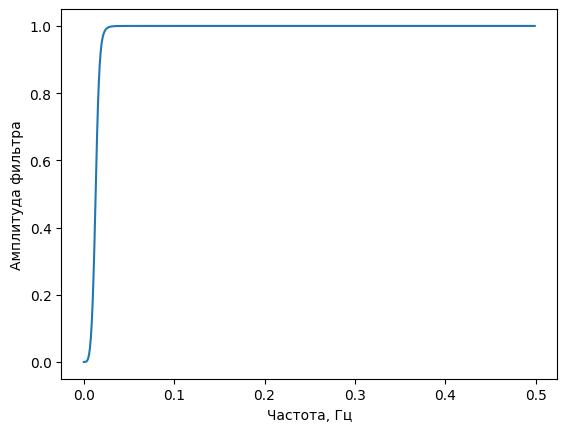

In [10]:
# рисунок 17 в дипломе

plt.plot(w, np.abs(h))
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда фильтра')
#plt.savefig('highpass_filter_freqResp.jpg')
plt.show()

In [11]:
import generate_areas as ga
from fringe_class import Fringe, FringeList
%load_ext autoreload
%autoreload 2

## Illustration for high-pass filter, filtering off the lowest 3 frequencies

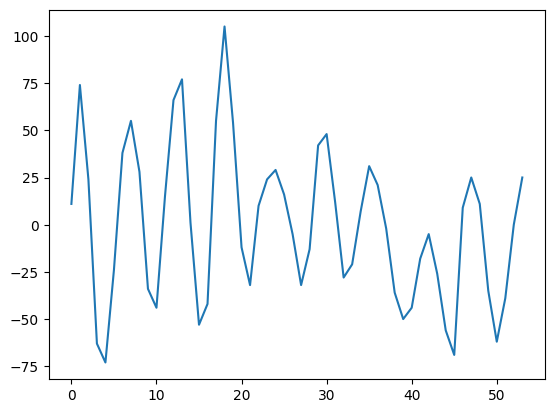

In [25]:
img_path = 'drop-211025-2/drop-0110.jpg'

sel = ga.SelectArea(img_path=img_path)
sel.select_roi()

fringe = sel.extract()
fringe.plot()

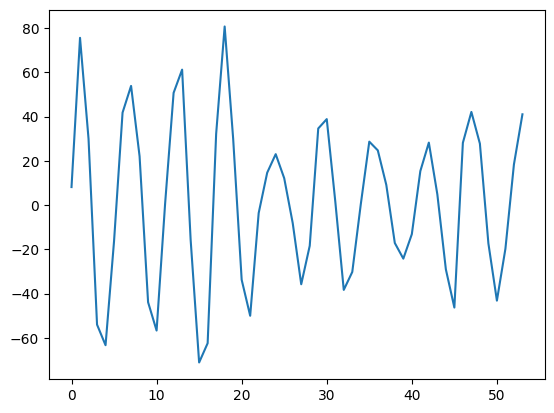

In [28]:
fringe_h = fringe.filter_low_frq(nl=5, inplace=False)
fringe_h.plot()

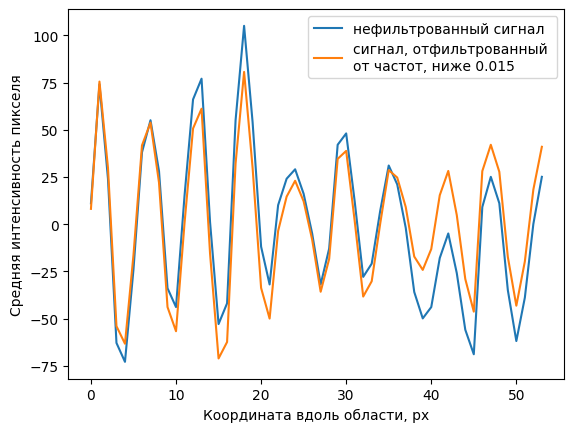

In [59]:
x = np.arange(fringe.sig_len)

plt.figure()

plt.plot(x, fringe.sig)
plt.plot(x, fringe_h.sig)
plt.xlabel("Координата вдоль области, px")
plt.ylabel("Средняя интенсивность пикселя")
plt.legend(labels=["нефильтрованный сигнал",f'сигнал, отфильтрованный \nот частот, ниже {f_cut}'], loc="upper right")

plt.savefig("filter_low_frq_demo.jpg")
plt.show()

## Illustration for Butterwort bandpass filter creation from spectral dencity distribution

In [38]:
import sig_analize as sa

In [51]:
def my_butter(sig, fs=1, N=4, rel_h = 0.7, nperseg = 250):
    # fs -sampling frequency

    fxx, Pxx_den = signal.welch(np.real(sig), fs = fs, nperseg=nperseg)
    fxx_len = len(fxx)
    
    peak = np.argmax(Pxx_den)
    width = signal.peak_widths(Pxx_den,[peak], rel_height = rel_h)
    
    Wn = [width[2]*fs/2/(fxx_len-1), width[3]*fs/2/(fxx_len-1)]
    
    btype = 'bandpass'

    b, a  = signal.butter(N, Wn, btype, fs = fs)
    w, h = signal.freqz(b, a, fs=fs)

    plt.figure()
    plt.plot(fxx, Pxx_den/np.max(Pxx_den))
    plt.hlines(width[1]/np.max(Pxx_den), *Wn, color= 'C2')
    plt.plot(w, np.abs(h))
    
    plt.xlabel("Частота, Гц")
    plt.ylabel("Нормированная амплитуда")
    plt.legend(["спектральная плотность \nмощности сигнала",
                "ширина пика на уровне 0.25",
                "амплитудная \nхарактеристика \nфильтра"], loc="upper right")

    plt.savefig('bandpass_filter_creation.jpg')
    plt.show()

    return b, a

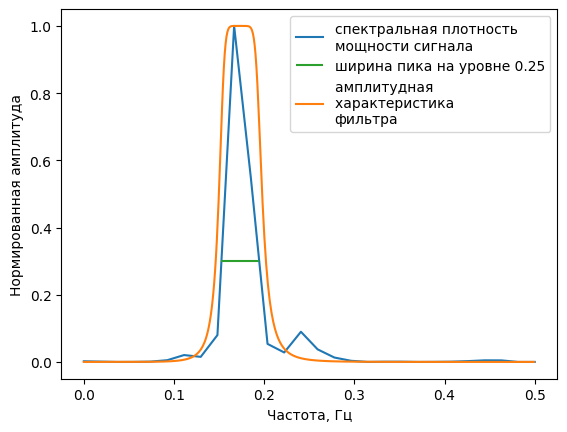

(array([ 0.00021781,  0.        , -0.00087125,  0.        ,  0.00130688,
         0.        , -0.00087125,  0.        ,  0.00021781]),
 array([  1.        ,  -3.40931065,   7.68229284, -11.01133924,
         12.01331211,  -9.26724282,   5.44112141,  -2.03043643,
          0.50133366]))

In [52]:
my_butter(sig=fringe_h.sig, nperseg=fringe_h.sig_len)

## Compare signals with different levels of filtration

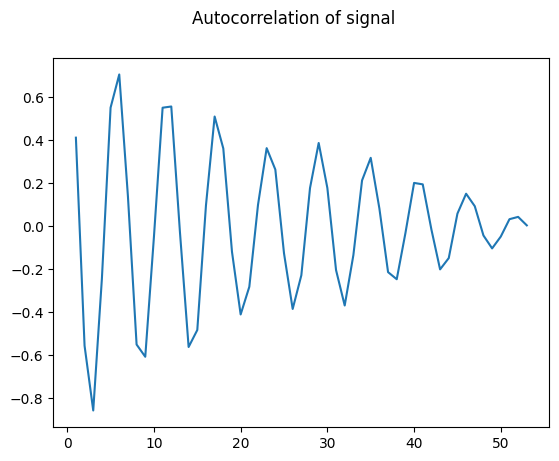

9


In [53]:
peak_count = fringe_h.count_peaks_of_autocorr(show=True)
print(peak_count)

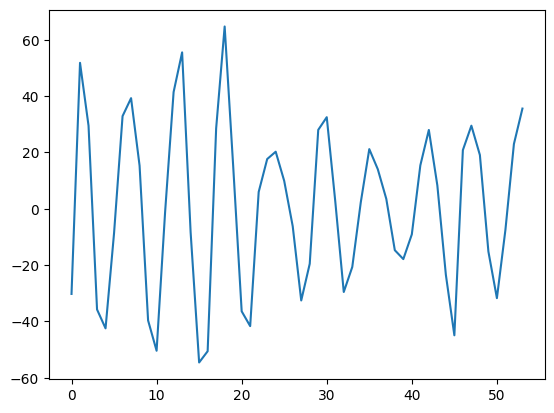

In [55]:
fringe_h8 = fringe_h.filter_low_frq(nl=peak_count-1,inplace=False)
fringe_h8.plot()

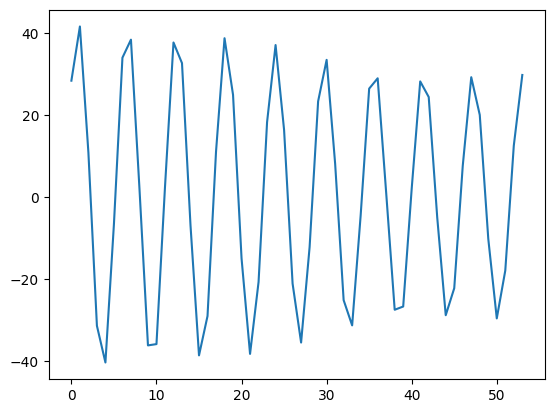

In [56]:
fringe_Wn = fringe_h8.filter_notch_Wn(border=4, updateWn=True, rel_h=0.5, nperseg_c=1, inplace=False)
fringe_Wn.plot()

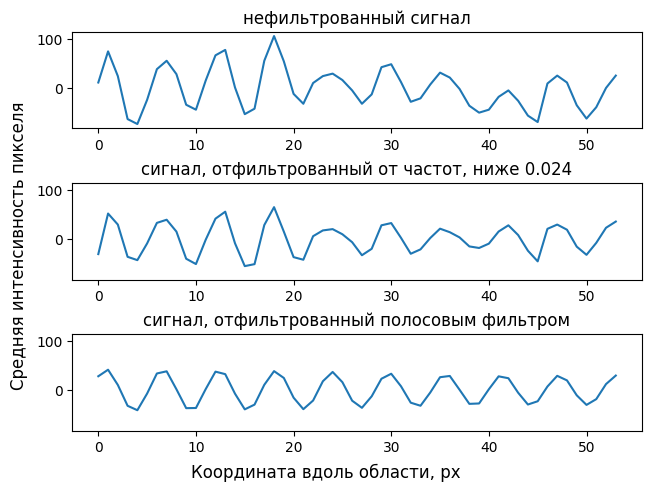

In [68]:
x = np.arange(fringe.sig_len)

fig, ax = plt.subplots(3, 1, layout="constrained", sharey=True)

ax[0].plot(x, fringe.sig)
ax[0].set_title("нефильтрованный сигнал")
ax[1].plot(x, fringe_h8.sig)
ax[1].set_title(f'сигнал, отфильтрованный от частот, ниже {f_cut/5*8}')
ax[2].plot(x, fringe_Wn.sig)
ax[2].set_title(f'сигнал, отфильтрованный полосовым фильтром')

fig.supxlabel("Координата вдоль области, px")
fig.supylabel("Средняя интенсивность пикселя")


plt.savefig("filter_signal_demo.jpg")
plt.show()

In [69]:
f, p_den = signal.welch(fringe.sig, fs = fs, nperseg=fringe.sig_len)
fh, p_denh = signal.welch(fringe_h8.sig, fs = fs, nperseg=fringe_h8.sig_len)
fw, p_denw = signal.welch(fringe_Wn.sig, fs = fs, nperseg=fringe_Wn.sig_len)

In [70]:
anal_y = signal.hilbert(np.real(fringe.sig))
ph = np.unwrap(np.angle(anal_y))

anal_y = signal.hilbert(np.real(fringe_h8.sig))
ph_h = np.unwrap(np.angle(anal_y))

anal_y = signal.hilbert(np.real(fringe_Wn.sig))
ph_w = np.unwrap(np.angle(anal_y))

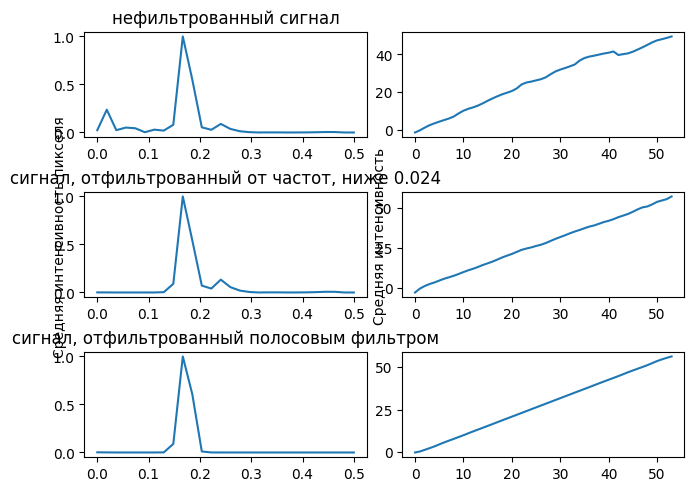

In [78]:
fig, ax = plt.subplots(3, 2, layout="constrained")

ax[0][0].plot(f, p_den/np.max(p_den))
ax[0][0].set_title("нефильтрованный сигнал")
ax[0][1].plot(x, ph)

ax[1][0].plot(fh, p_denh/np.max(p_denh))
ax[1][0].set_title(f'сигнал, отфильтрованный от частот, ниже {f_cut/5*8}')
ax[1][1].plot(x, ph_h)

ax[2][0].plot(fw, p_denw/np.max(p_denw))
ax[2][0].set_title(f'сигнал, отфильтрованный полосовым фильтром')
ax[2][1].plot(x, ph_w)

#fig.supxlabel("Координата вдоль области, px")
#fig.supylabel("Средняя интенсивность пикселя")
ax_w1 = fig.add_subplot(1,2,1, frameon=False)
ax_w1.tick_params(labelcolor='none', left=False, bottom=False)
ax_w1.set_ylabel("Средняя интенсивность пикселя")

ax_w2 = fig.add_subplot(1,2,2, frameon=False)
ax_w2.tick_params(labelcolor='none', left=False, bottom=False)
ax_w2.set_ylabel("Средняя интенсивность")

ax_h1 = fig.add_subplot(2,1,1, frameon=False)
ax_h1.tick_params(labelcolor='none', left=False, bottom=False)
ax_h1.set_xlabel("Средняя интенсивность")

ax_h2 = fig.add_subplot(2,1,2, frameon=False)
ax_h2.tick_params(labelcolor='none', left=False, bottom=False)
ax_h2.set_xlabel("Средняя интенсивность")




plt.savefig("filter_signal_specDen_phase.jpg")
plt.show()